**Author**: Felipe Matheus <br>
**Start Date**: 16/04/2026 <br>
**End Date**: --/--/2026 <br>
**Related Links**:
- `modeling_clusterization.ipynb` — baseline clustering on raw compositions
- `data/structured/Periodic GroupElement Added.tsv` — conductivity reduction factors

**Objective:**

Re-cluster the same 9 SPECTRO Cu-10-F samples using two new feature representations
derived from domain knowledge about how each element reduces copper conductivity:

- **Group % features** — for each periodic group (I–VIII), the sum of concentrations
  of all elements in that group.
- **Reduction impact features** — for each group, the weighted sum
  `Σ(conc_i × factor_i)`, where `factor_i` is the conductivity reduction coefficient
  from the literature table. A `total_reduction` column aggregates all groups.

Before each clustering, a PCA variance analysis (2–5 PCs) quantifies how compactly
each feature space can be represented.

---
## 1 · Setup

In [1]:
import os
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.DataLoader import DataLoader as load
from src.feature_engineering.FeatureEngineering import FeatureEngineering as feng
from src.modeling.modeling import Modeling as modl
from src.visualization.Plots import Plots as plot

warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

In [2]:
SEED = 42
KS   = (2, 3, 4)
N_MC = 100
ALGOS = ["KMeans", "KMeans++", "Hierarchical", "GMM"]
MAX_PCS = 5

# Feature-selection knobs (applied to the raw composition before periodic transform)
DROP_DISCARDED = True   # True → remove Cu + near-zero-variance elements first
TIERS          = None   # None → keep all remaining elements

PERIODIC_TSV = os.path.abspath(
    os.path.join('../..', 'data', 'structured', 'Periodic GroupElement Added.tsv')
)

---
## 2 · Load data

In [3]:
compositions_path = os.path.abspath(os.path.join('../../data/raw/elements_composition'))
if compositions_path not in sys.path:
    sys.path.append(compositions_path)

from compositions import ALL_SAMPLES

print(f"{len(ALL_SAMPLES)} samples: {list(ALL_SAMPLES.keys())}")

9 samples: ['1A sac1', '1A sac2', '1B sac1', '1B sac2', '1B sac3', '1B sac4', '1B sac6', '2N sac1', '2N sac2']


In [4]:
periodic_df = feng.load_periodic_table(PERIODIC_TSV)
print(f"Periodic table: {len(periodic_df)} elements across groups: "
      f"{sorted(periodic_df['group'].unique())}")
periodic_df

Periodic table: 16 elements across groups: ['I', 'II', 'III', 'IV', 'V', 'VI', 'VIII']


,symbol,group,factor,atomic_weight
0,Ag,I,6.0,108.0
1,Au,I,10.0,197.0
2,Zn,II,30.0,65.0
3,Cd,II,9.0,112.0
4,Al,III,500.0,27.0
5,Si,IV,70.0,28.0
6,Sn,IV,67.0,119.0
7,Pb,IV,3.0,207.0
8,P,V,3000.0,31.0
9,As,V,720.0,75.0


---
## 3 · Build raw datasets

`DROP_DISCARDED=True` removes Cu (the base matrix) and near-zero-variance elements,
leaving only elements with meaningful variation — these are then transformed into
the periodic-group feature sets in section 4.

In [5]:
df_A = feng.build_dataset(
    ALL_SAMPLES, below_limit_zero=False, mc_augment=False,
    tiers=TIERS, drop_discarded=DROP_DISCARDED,
)
df_B = feng.build_dataset(
    ALL_SAMPLES, below_limit_zero=True, mc_augment=True,
    n_mc=N_MC, seed=SEED, tiers=TIERS, drop_discarded=DROP_DISCARDED,
)
df_C = feng.build_dataset(
    ALL_SAMPLES, below_limit_zero=False, mc_augment=True,
    n_mc=N_MC, seed=SEED, tiers=TIERS, drop_discarded=DROP_DISCARDED,
)

print(f"Dataset A: {df_A.shape}   (columns: {list(df_A.columns)})")
print(f"Dataset B: {df_B.shape}")
print(f"Dataset C: {df_C.shape}")

Dataset A: (9, 13)   (columns: ['Zn', 'Pb', 'Sn', 'P', 'Fe', 'Ni', 'Si', 'Mg', 'As', 'Sb', 'Ag', 'B', 'Te'])
Dataset B: (900, 13)
Dataset C: (900, 13)


---
## 4 · Build periodic feature datasets

From each raw dataset we derive two compact representations:

| Feature set | Columns | Description |
|---|---|---|
| **Group %** | `group_{G}_pct` | Sum of concentrations (%) for all elements in group G |
| **Reduction impact** | `reduction_{G}`, `total_reduction` | `Σ(conc_i × factor_i)` per group; domain-weighted conductivity damage |

In [ ]:
# ── Group percentage features ──────────────────────────────────────────────
df_A_group = feng.build_group_pct(df_A, periodic_df) #TODO ENTENDER ISSO 
df_B_group = feng.build_group_pct(df_B, periodic_df)
df_C_group = feng.build_group_pct(df_C, periodic_df)

# ── Reduction impact features ──────────────────────────────────────────────
df_A_reduc = feng.build_reduction_impact(df_A, periodic_df)
df_B_reduc = feng.build_reduction_impact(df_B, periodic_df)
df_C_reduc = feng.build_reduction_impact(df_C, periodic_df)

print("Group % columns  :", list(df_C_group.columns))
print("Reduction columns:", list(df_C_reduc.columns))
print(f"\nDataset C — group shape  : {df_C_group.shape}")
print(f"Dataset C — reduc shape  : {df_C_reduc.shape}")

Group % columns  : ['group_I_pct', 'group_II_pct', 'group_III_pct', 'group_IV_pct', 'group_V_pct', 'group_VI_pct', 'group_VIII_pct', 'group_Other_pct']
Reduction columns: ['reduction_I', 'reduction_II', 'reduction_III', 'reduction_IV', 'reduction_V', 'reduction_VI', 'reduction_VIII', 'total_reduction']

Dataset C — group shape  : (900, 8)
Dataset C — reduc shape  : (900, 8)


In [22]:
df_A_reduc

,reduction_I,reduction_II,reduction_III,reduction_IV,reduction_V,reduction_VI,reduction_VIII,total_reduction
sample,,,,,,,,
1A sac1,0.00486,0.030,0.0,0.0843,1.5438,0.0068,0.1540,1.82376
1A sac2,0.00486,0.030,0.0,0.0843,1.5438,0.0076,0.1540,1.82456
1B sac1,0.00558,0.042,0.0,0.9958,1.5556,0.0080,0.1680,2.77498
1B sac2,0.00570,0.033,0.0,0.3104,1.5346,0.0080,0.1232,2.01490
1B sac3,0.00438,0.042,0.0,0.3176,1.6348,0.0084,0.1106,2.11778
1B sac4,0.00576,0.303,0.0,1.4682,1.6084,0.0116,0.2100,3.60696
1B sac6,0.00474,0.030,0.0,1.3662,1.7200,0.0088,0.1260,3.25574
2N sac1,0.00660,0.183,0.0,0.5576,1.6296,0.0084,0.1820,2.56720
2N sac2,0.00492,0.030,0.0,1.3340,1.7868,0.0080,0.1680,3.33172


In [23]:
df_A

,Zn,Pb,Sn,P,Fe,Ni,Si,Mg,As,Sb,Ag,B,Te
sample,,,,,,,,,,,,,
1A sac1,0.0010,0.0003,0.0002,0.00020,0.00110,0.00020,0.00100,0.00026,0.00044,0.0033,0.00081,0.00047,0.0017
1A sac2,0.0010,0.0003,0.0002,0.00020,0.00110,0.00020,0.00100,0.00026,0.00044,0.0033,0.00081,0.00047,0.0019
1B sac1,0.0014,0.0003,0.0137,0.00020,0.00120,0.00020,0.00110,0.00021,0.00043,0.0034,0.00093,0.00051,0.0020
1B sac2,0.0011,0.0003,0.0037,0.00020,0.00088,0.00020,0.00088,0.00017,0.00048,0.0031,0.00095,0.00043,0.0020
1B sac3,0.0014,0.0100,0.0033,0.00020,0.00079,0.00020,0.00095,0.00021,0.00054,0.0034,0.00073,0.00040,0.0021
1B sac4,0.0101,0.0053,0.0199,0.00026,0.00150,0.00020,0.00170,0.00031,0.00057,0.0022,0.00096,0.00048,0.0029
1B sac6,0.0010,0.0003,0.0195,0.00020,0.00090,0.00020,0.00084,0.00017,0.00050,0.0040,0.00079,0.00043,0.0022
2N sac1,0.0061,0.0332,0.0060,0.00020,0.00130,0.00034,0.00080,0.00017,0.00048,0.0036,0.00110,0.00046,0.0021
2N sac2,0.0010,0.3020,0.0055,0.00020,0.00120,0.00020,0.00085,0.00017,0.00054,0.0042,0.00082,0.00045,0.0020


In [24]:
periodic_df

,symbol,group,factor,atomic_weight
0,Ag,I,6.0,108.0
1,Au,I,10.0,197.0
2,Zn,II,30.0,65.0
3,Cd,II,9.0,112.0
4,Al,III,500.0,27.0
5,Si,IV,70.0,28.0
6,Sn,IV,67.0,119.0
7,Pb,IV,3.0,207.0
8,P,V,3000.0,31.0
9,As,V,720.0,75.0


In [7]:
# Preview Dataset A (9 point estimates) — easy to read
print("── Group % (Dataset A) ──")
display(df_A_group)
print("\n── Reduction impact (Dataset A) ──")
display(df_A_reduc)

── Group % (Dataset A) ──


,group_I_pct,group_II_pct,group_III_pct,group_IV_pct,group_V_pct,group_VI_pct,group_VIII_pct,group_Other_pct
sample,,,,,,,,
1A sac1,0.00081,0.0010,0.0,0.00150,0.00394,0.0017,0.00110,0.00093
1A sac2,0.00081,0.0010,0.0,0.00150,0.00394,0.0019,0.00110,0.00093
1B sac1,0.00093,0.0014,0.0,0.01510,0.00403,0.0020,0.00120,0.00092
1B sac2,0.00095,0.0011,0.0,0.00488,0.00378,0.0020,0.00088,0.00080
1B sac3,0.00073,0.0014,0.0,0.01425,0.00414,0.0021,0.00079,0.00081
1B sac4,0.00096,0.0101,0.0,0.02690,0.00303,0.0029,0.00150,0.00099
1B sac6,0.00079,0.0010,0.0,0.02064,0.00470,0.0022,0.00090,0.00080
2N sac1,0.00110,0.0061,0.0,0.04000,0.00428,0.0021,0.00130,0.00097
2N sac2,0.00082,0.0010,0.0,0.30835,0.00494,0.0020,0.00120,0.00082



── Reduction impact (Dataset A) ──


,reduction_I,reduction_II,reduction_III,reduction_IV,reduction_V,reduction_VI,reduction_VIII,total_reduction
sample,,,,,,,,
1A sac1,0.00486,0.030,0.0,0.0843,1.5438,0.0068,0.1540,1.82376
1A sac2,0.00486,0.030,0.0,0.0843,1.5438,0.0076,0.1540,1.82456
1B sac1,0.00558,0.042,0.0,0.9958,1.5556,0.0080,0.1680,2.77498
1B sac2,0.00570,0.033,0.0,0.3104,1.5346,0.0080,0.1232,2.01490
1B sac3,0.00438,0.042,0.0,0.3176,1.6348,0.0084,0.1106,2.11778
1B sac4,0.00576,0.303,0.0,1.4682,1.6084,0.0116,0.2100,3.60696
1B sac6,0.00474,0.030,0.0,1.3662,1.7200,0.0088,0.1260,3.25574
2N sac1,0.00660,0.183,0.0,0.5576,1.6296,0.0084,0.1820,2.56720
2N sac2,0.00492,0.030,0.0,1.3340,1.7868,0.0080,0.1680,3.33172


---
## 5 · PCA variance analysis (2 – 5 PCs)

Before clustering each feature space we ask: **how many principal components
are needed to faithfully represent it?**

Bars show the fraction of variance explained by each individual PC.
The red line shows the cumulative total — annotated at every point so you
can read off directly how much of the signal is kept at 2, 3, 4, or 5 PCs.

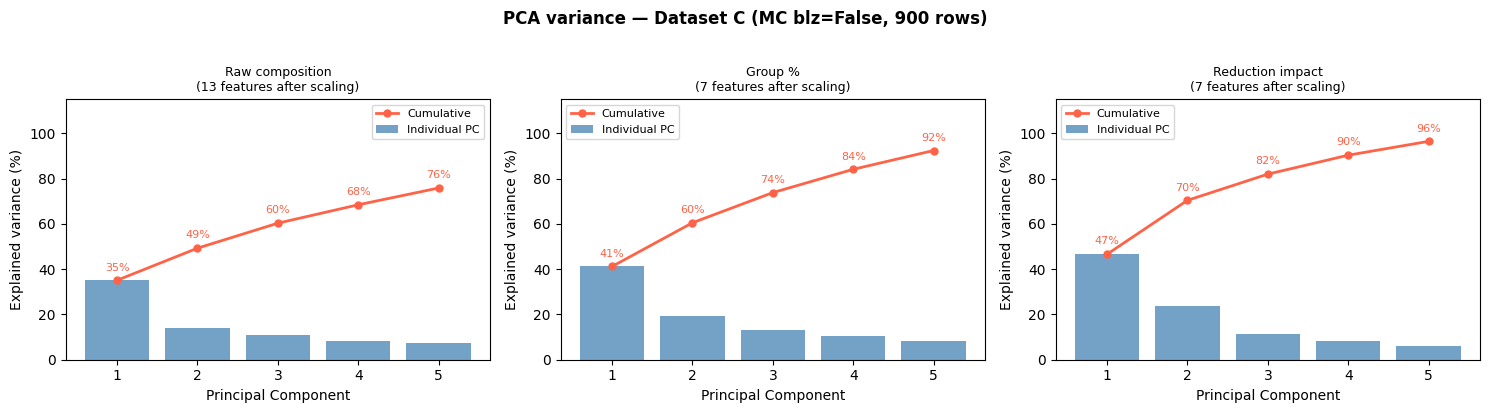

In [8]:
# Compare all three feature spaces on Dataset C (900 rows — most stable PCA)
pca_raw   = modl.pca_variance_analysis(df_C,       MAX_PCS, SEED)
pca_group = modl.pca_variance_analysis(df_C_group, MAX_PCS, SEED)
pca_reduc = modl.pca_variance_analysis(df_C_reduc, MAX_PCS, SEED)

plot.plot_pca_variance(
    analyses={
        "Raw composition": pca_raw,
        "Group %":         pca_group,
        "Reduction impact":pca_reduc,
    },
    title="PCA variance — Dataset C (MC blz=False, 900 rows)",
)

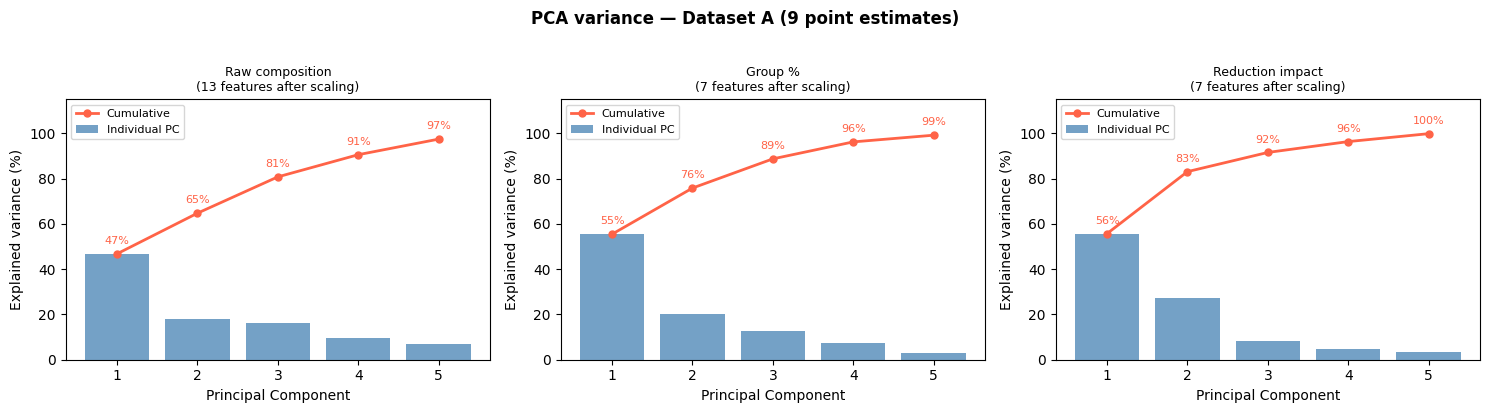

In [9]:
# Same comparison on Dataset A (9 point estimates) — limited by n_samples
pca_raw_A   = modl.pca_variance_analysis(df_A,       MAX_PCS, SEED)
pca_group_A = modl.pca_variance_analysis(df_A_group, MAX_PCS, SEED)
pca_reduc_A = modl.pca_variance_analysis(df_A_reduc, MAX_PCS, SEED)

plot.plot_pca_variance(
    analyses={
        "Raw composition": pca_raw_A,
        "Group %":         pca_group_A,
        "Reduction impact":pca_reduc_A,
    },
    title="PCA variance — Dataset A (9 point estimates)",
)

---
## 6 · Clustering — Group percentage features

Each sample is represented by the summed concentration of all elements in each
periodic group.  This collapses ~13 raw features into ~8 group columns, asking:
*does which **chemical family** dominates matter more than which specific element?*

In [10]:
summary_A_group, results_A_group = modl.run_all(df_A_group, ks=KS, seed=SEED)
summary_A_group

Silhouette  Inertia     BIC     AIC
Algorithm    K                                     
GMM          2      0.3725      NaN  -15.23  -29.24
             3      0.1944      NaN -217.46 -238.56
             4      0.2737      NaN -221.08 -249.29
Hierarchical 2      0.3972      NaN     NaN     NaN
             3      0.2113      NaN     NaN     NaN
             4      0.2479      NaN     NaN     NaN
KMeans       2      0.3725  34.5537     NaN     NaN
             3      0.3156  22.1820     NaN     NaN
             4      0.2737  14.0801     NaN     NaN
KMeans++     2      0.3725  34.5537     NaN     NaN
             3      0.3156  22.1820     NaN     NaN
             4      0.2479  13.1745     NaN     NaN

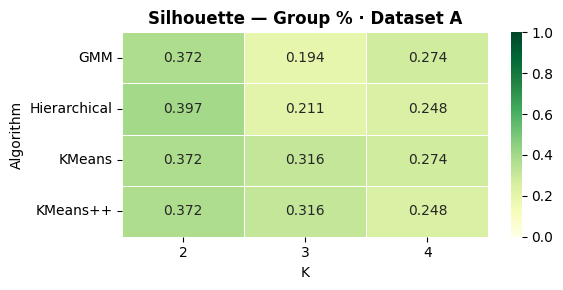

In [11]:
plot.plot_silhouette_heatmap(summary_A_group,
                              "Silhouette — Group % · Dataset A")

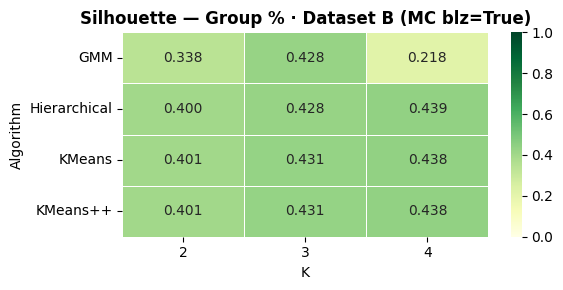

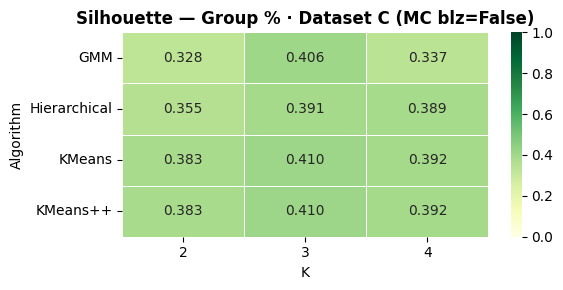

In [12]:
summary_B_group, results_B_group = modl.run_all(df_B_group, ks=KS, seed=SEED)
summary_C_group, results_C_group = modl.run_all(df_C_group, ks=KS, seed=SEED)

plot.plot_silhouette_heatmap(summary_B_group,
                              "Silhouette — Group % · Dataset B (MC blz=True)")
plot.plot_silhouette_heatmap(summary_C_group,
                              "Silhouette — Group % · Dataset C (MC blz=False)")

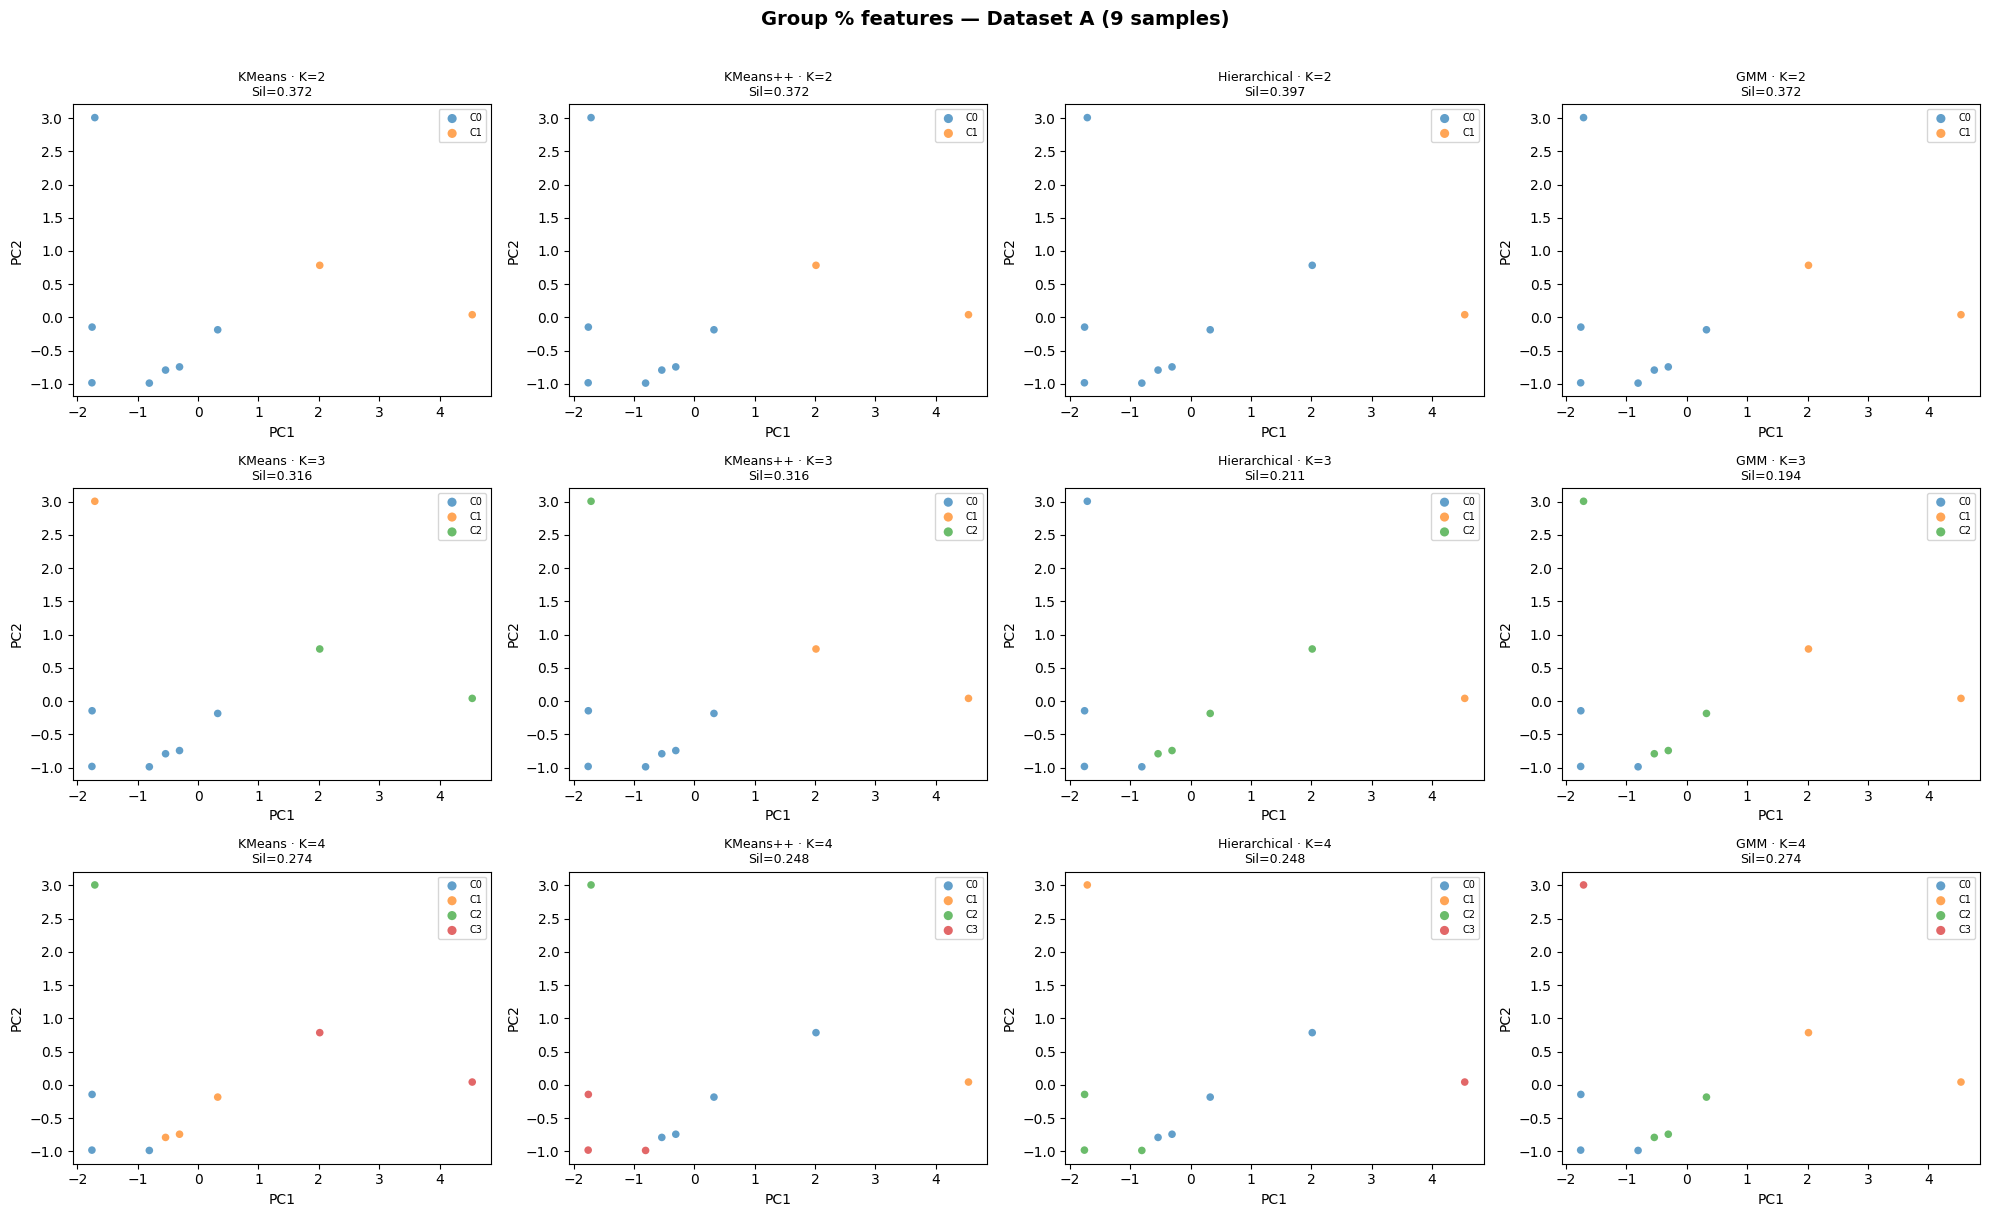

In [13]:
plot.plot_clusters_pca(
    df_feat=df_A_group, algos=ALGOS, results=results_A_group,
    title="Group % features — Dataset A (9 samples)", ks=KS,
)

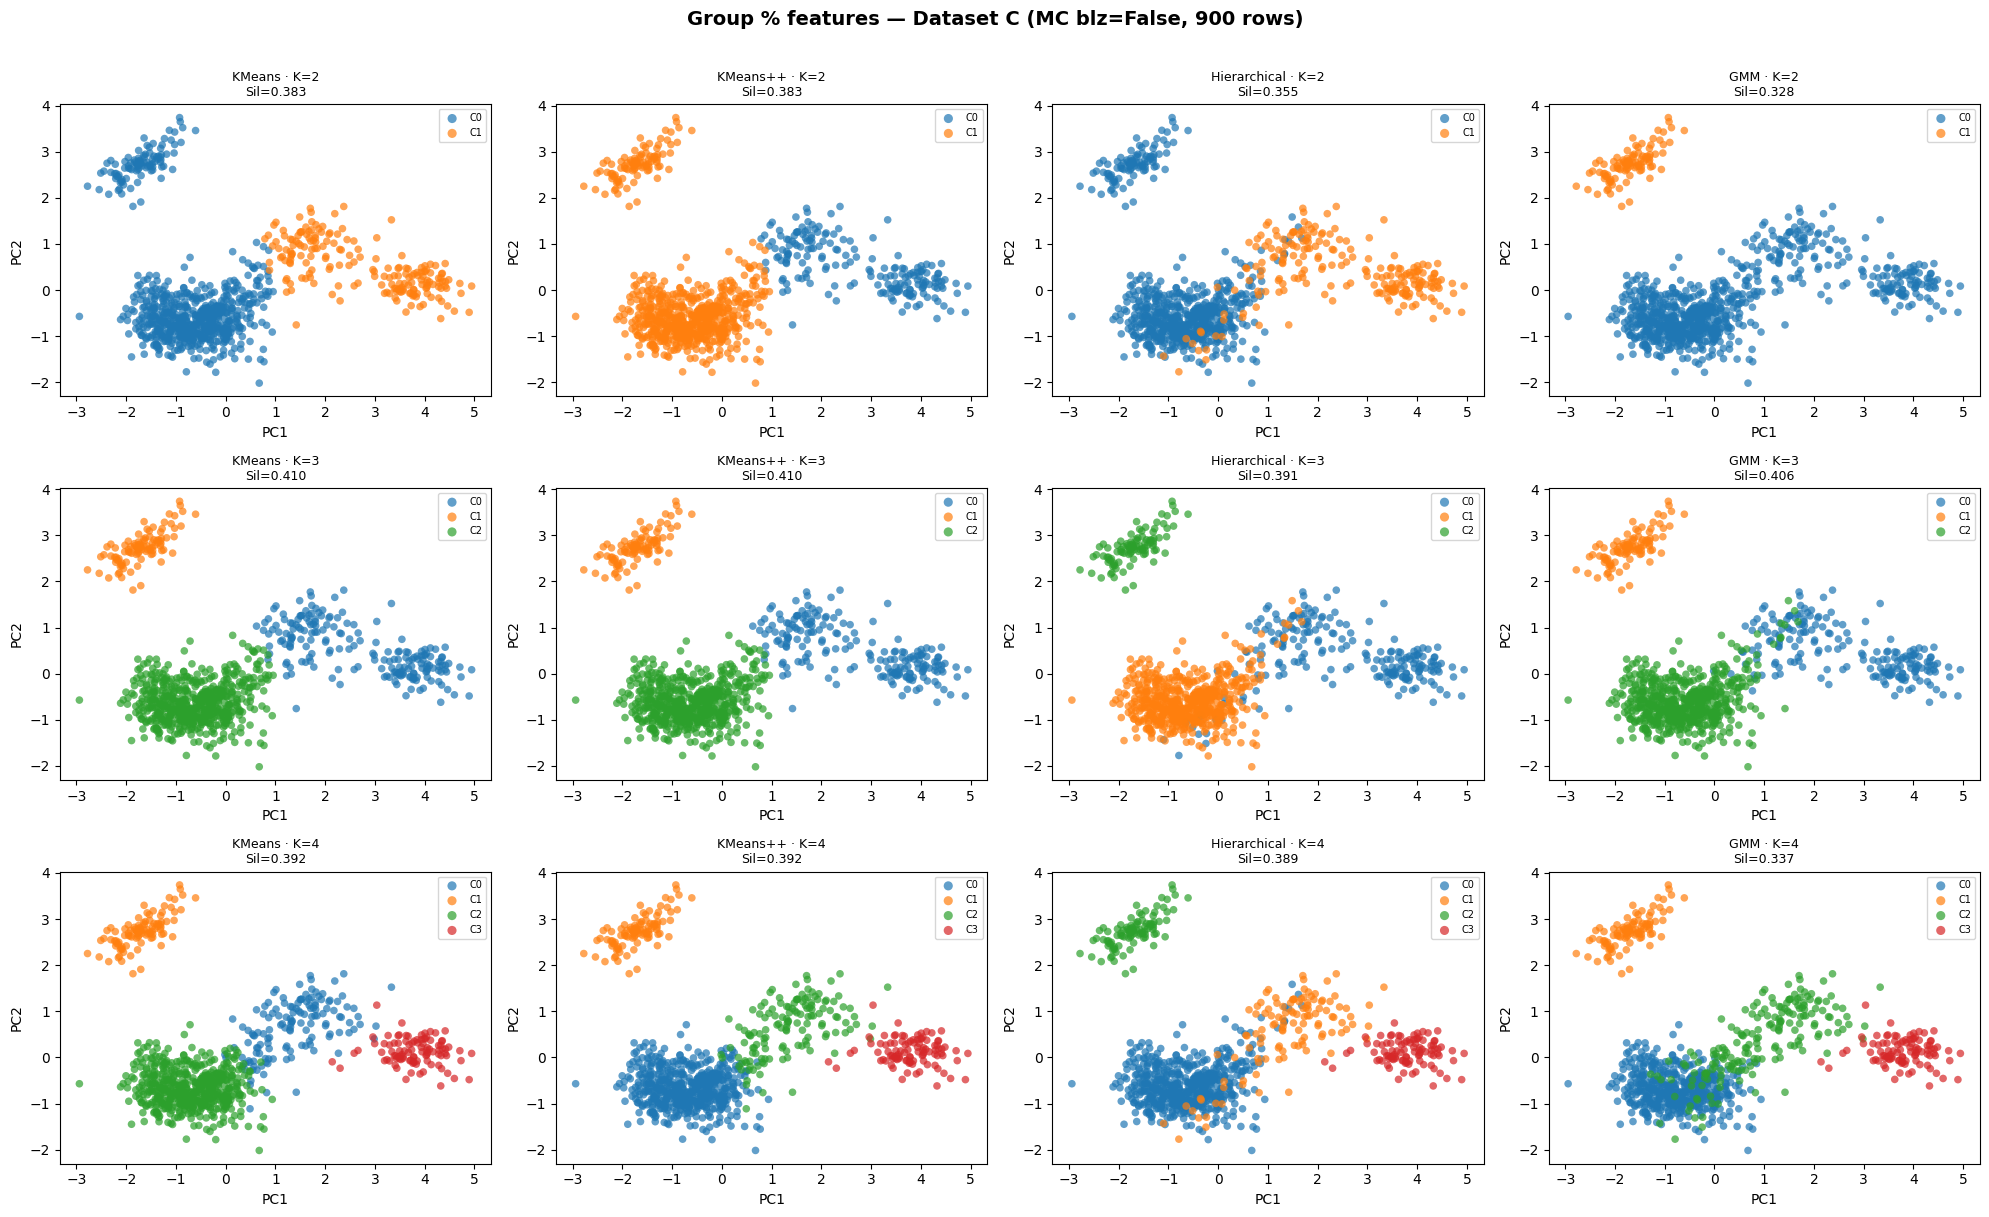

In [14]:
plot.plot_clusters_pca(
    df_feat=df_C_group, algos=ALGOS, results=results_C_group,
    title="Group % features — Dataset C (MC blz=False, 900 rows)", ks=KS,
)

---
## 7 · Clustering — Reduction impact features

Each sample is represented by the domain-weighted sum `Σ(conc_i × factor_i)` per
group.  High-factor elements (P = 3000, Al = 500, As = 720) dominate their groups.
The `total_reduction` column integrates all groups into a single conductivity-damage
proxy.

In [15]:
summary_A_reduc, results_A_reduc = modl.run_all(df_A_reduc, ks=KS, seed=SEED)
summary_A_reduc

Silhouette  Inertia     BIC     AIC
Algorithm    K                                     
GMM          2      0.2965      NaN  -85.08  -99.08
             3      0.3556      NaN -216.05 -237.15
             4      0.3341      NaN -195.54 -223.74
Hierarchical 2      0.2965      NaN     NaN     NaN
             3      0.3172      NaN     NaN     NaN
             4      0.3341      NaN     NaN     NaN
KMeans       2      0.2820  37.0111     NaN     NaN
             3      0.3172  21.9692     NaN     NaN
             4      0.3341  10.9493     NaN     NaN
KMeans++     2      0.3069  38.4824     NaN     NaN
             3      0.3547  20.5944     NaN     NaN
             4      0.3341  10.9493     NaN     NaN

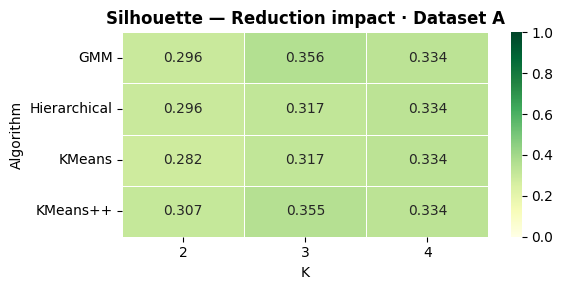

In [16]:
plot.plot_silhouette_heatmap(summary_A_reduc,
                              "Silhouette — Reduction impact · Dataset A")

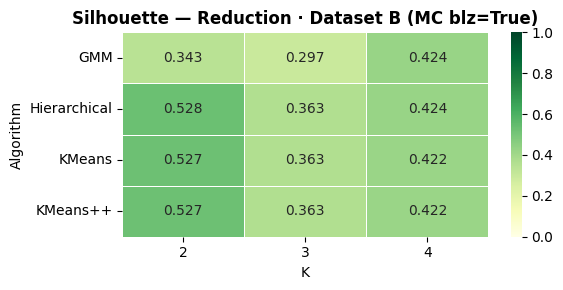

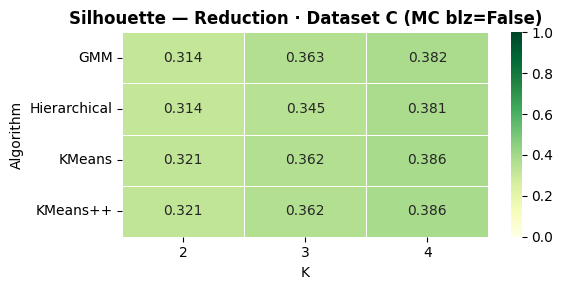

In [17]:
summary_B_reduc, results_B_reduc = modl.run_all(df_B_reduc, ks=KS, seed=SEED)
summary_C_reduc, results_C_reduc = modl.run_all(df_C_reduc, ks=KS, seed=SEED)

plot.plot_silhouette_heatmap(summary_B_reduc,
                              "Silhouette — Reduction · Dataset B (MC blz=True)")
plot.plot_silhouette_heatmap(summary_C_reduc,
                              "Silhouette — Reduction · Dataset C (MC blz=False)")

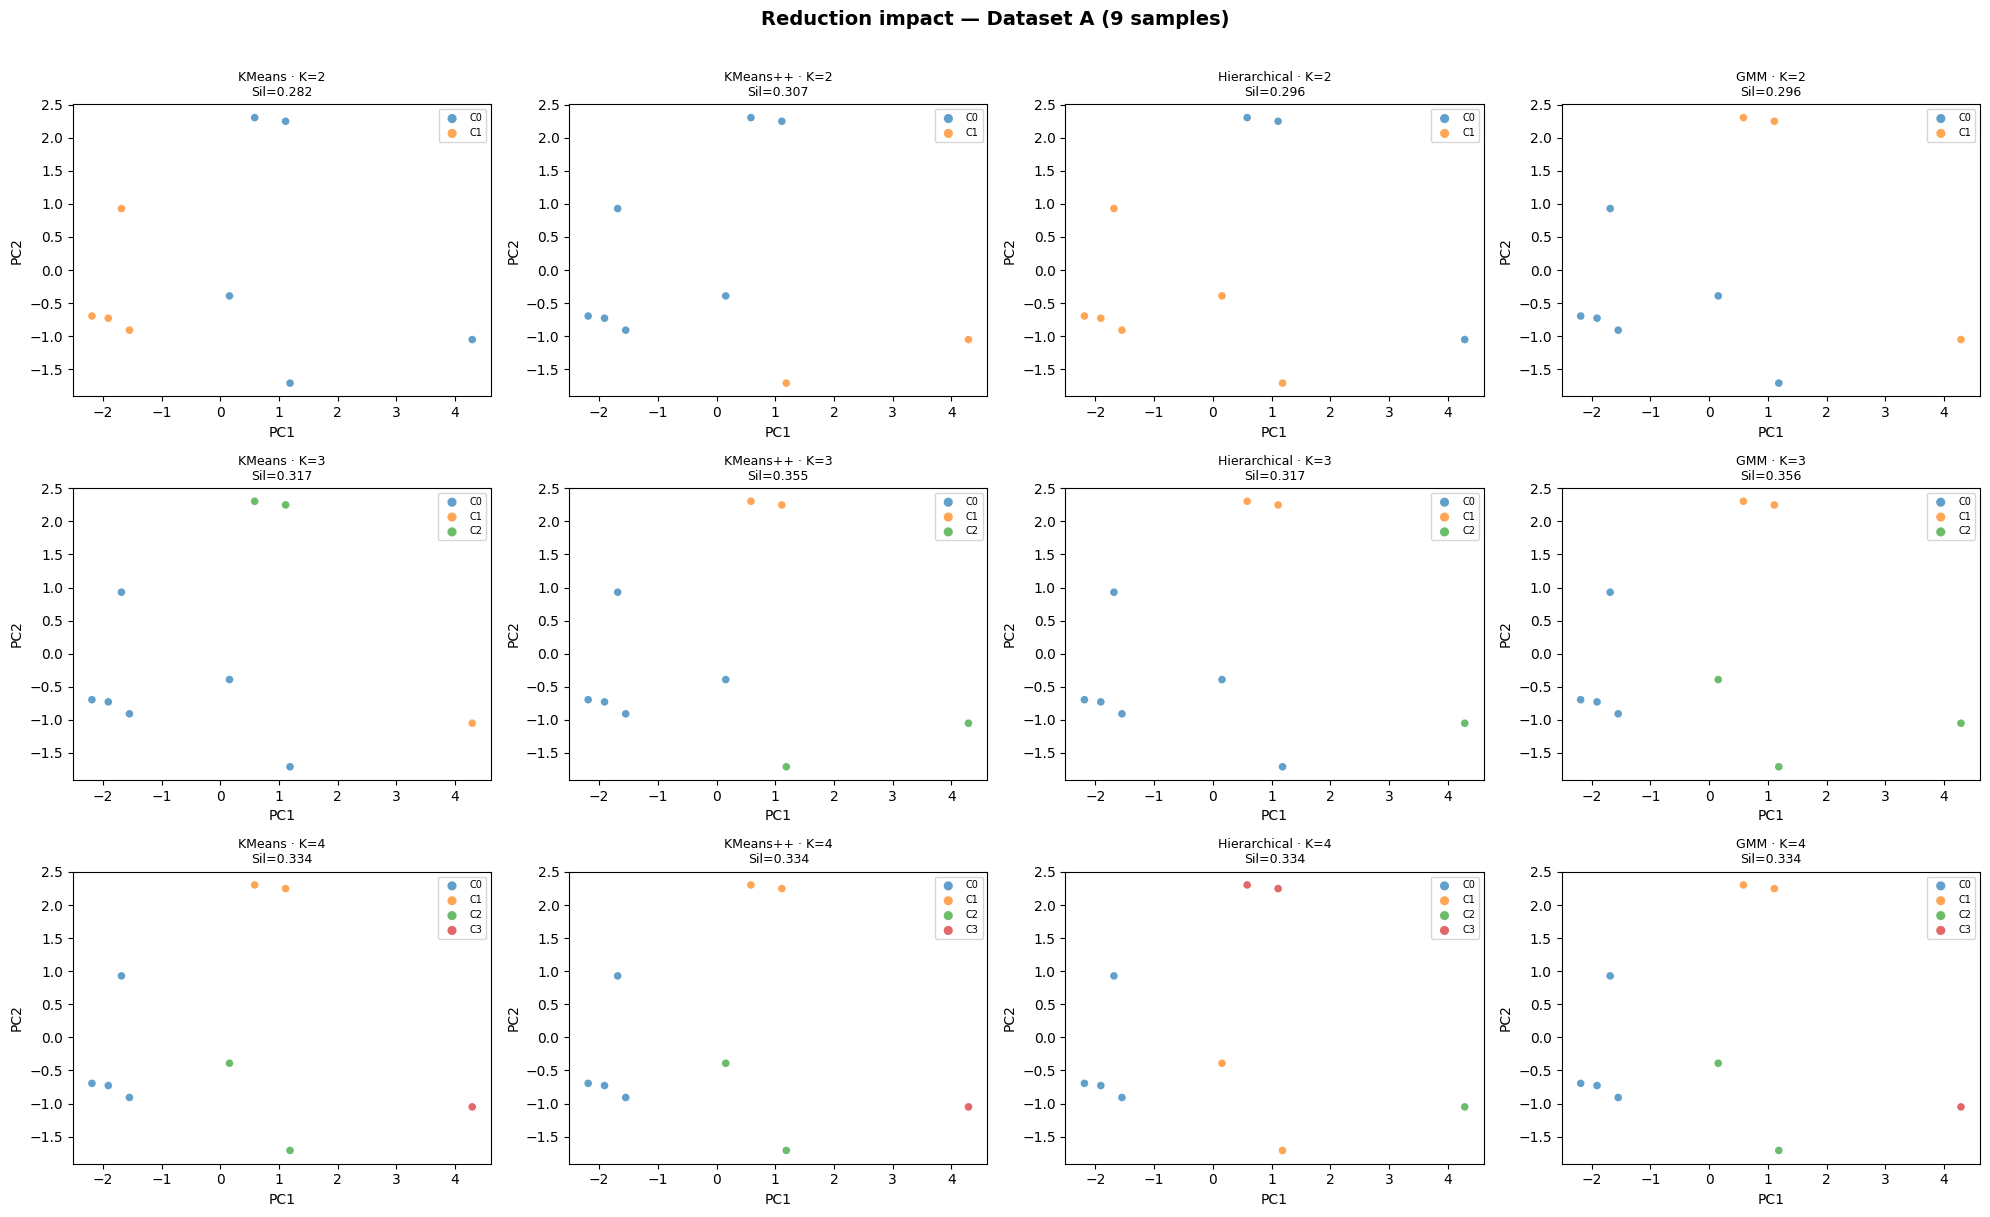

In [18]:
plot.plot_clusters_pca(
    df_feat=df_A_reduc, algos=ALGOS, results=results_A_reduc,
    title="Reduction impact — Dataset A (9 samples)", ks=KS,
)

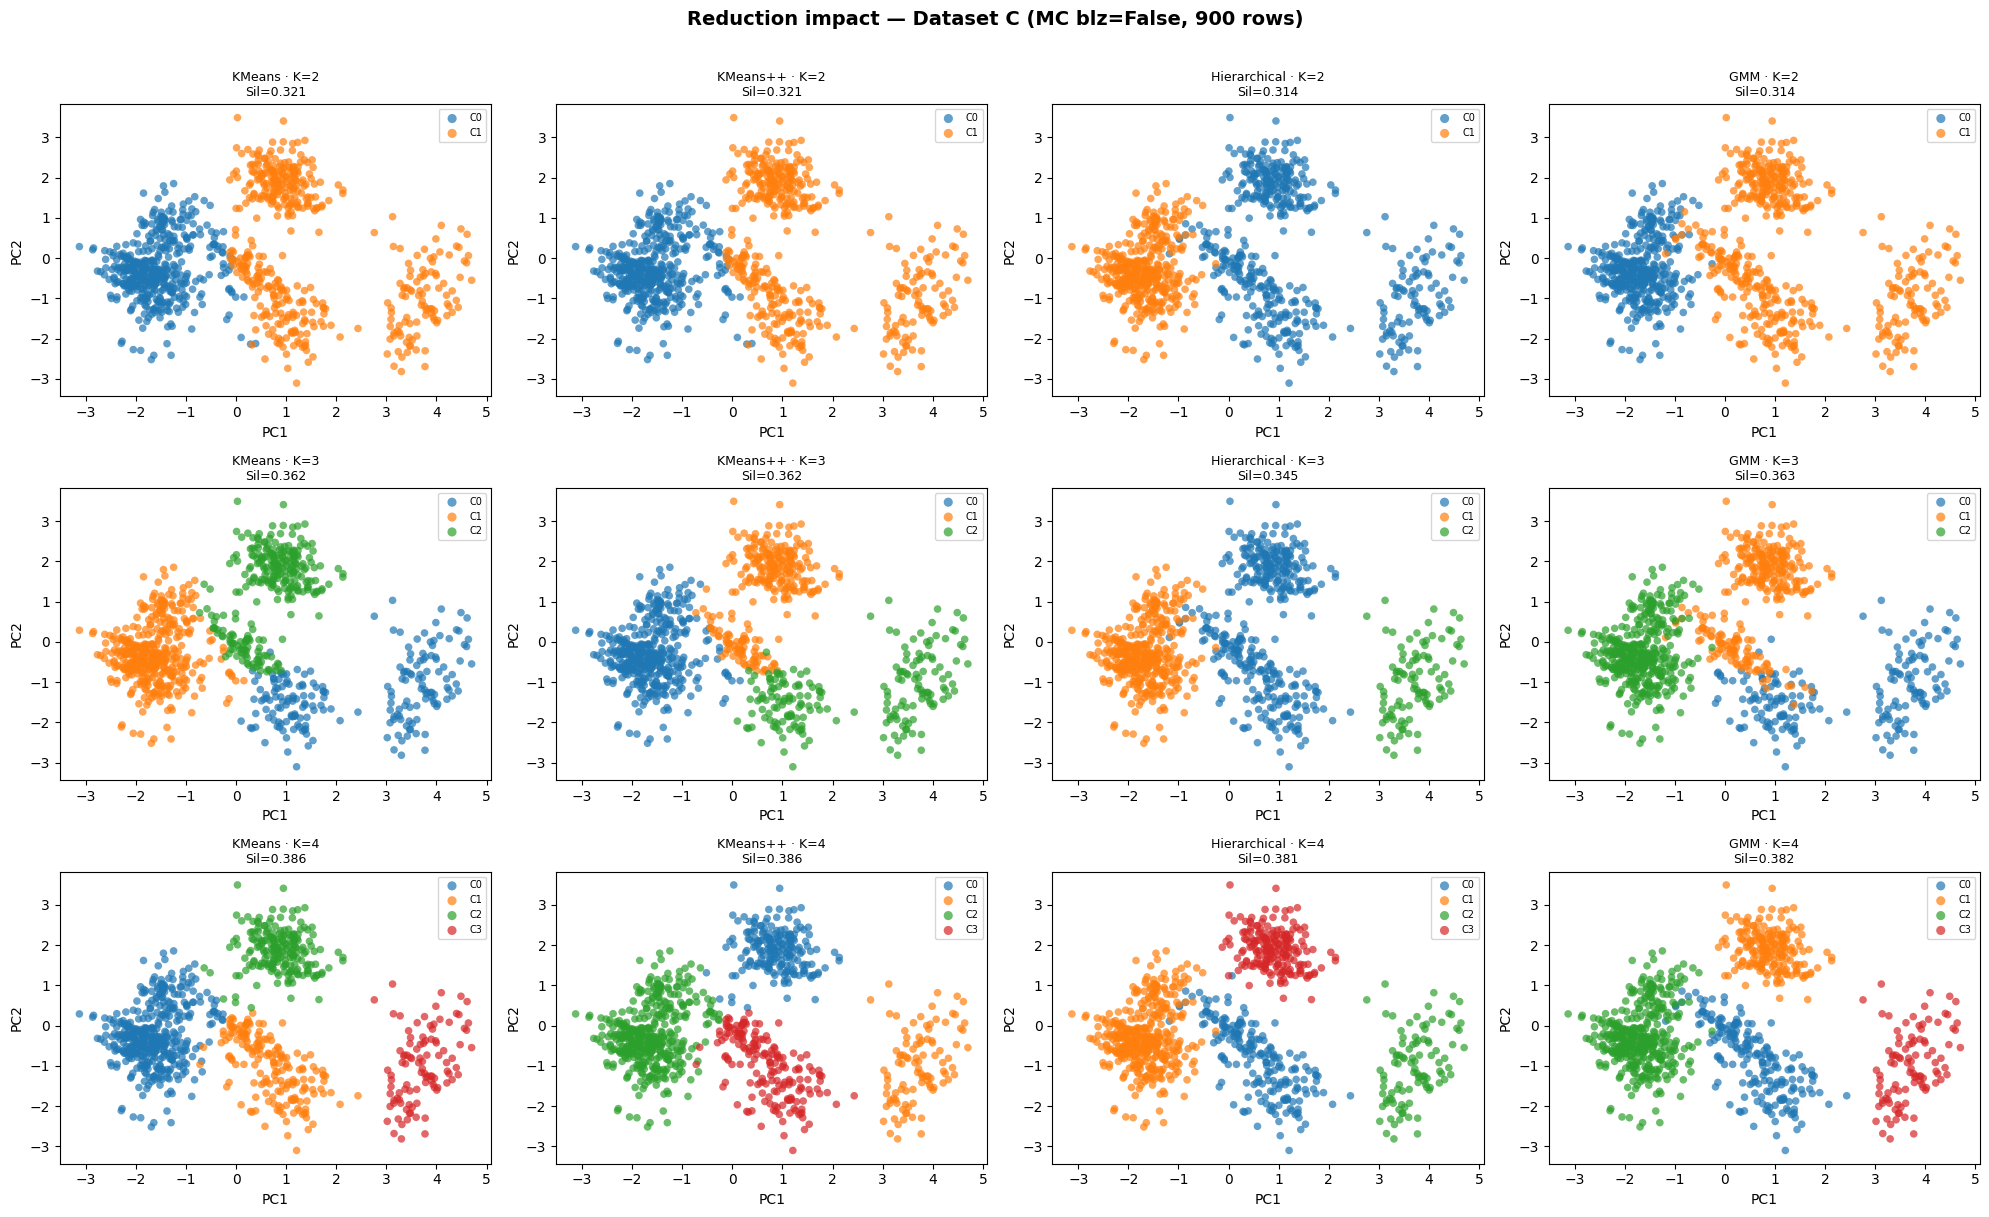

In [19]:
plot.plot_clusters_pca(
    df_feat=df_C_reduc, algos=ALGOS, results=results_C_reduc,
    title="Reduction impact — Dataset C (MC blz=False, 900 rows)", ks=KS,
)

---
## 8 · Cross-feature comparison

Compare Silhouette scores across the three feature representations on Dataset C.
Consistent cluster structure across representations strengthens confidence in the
groupings; divergence reveals features that add or lose discriminative signal.

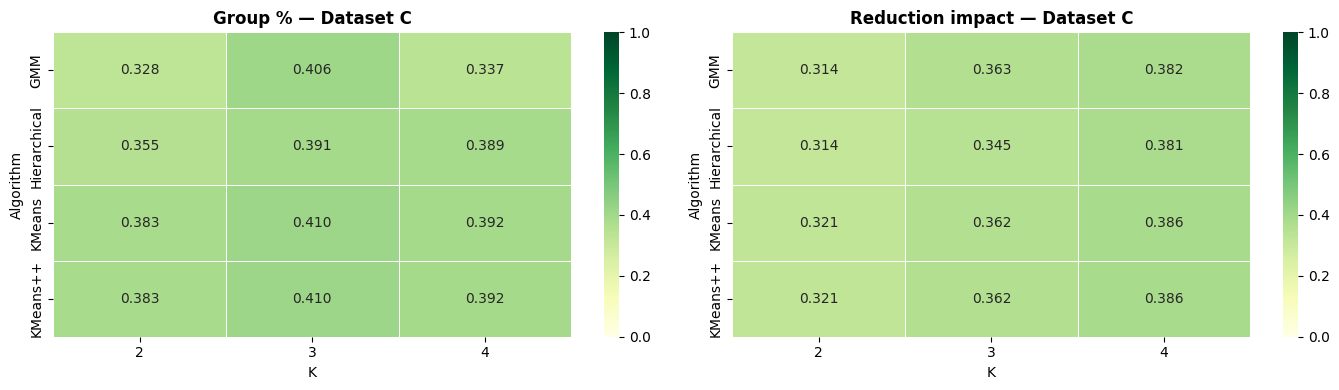

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

summaries_C = {
    "Group %":          summary_C_group,
    "Reduction impact": summary_C_reduc,
}
fig, axes = plt.subplots(1, len(summaries_C), figsize=(7 * len(summaries_C), 4))
for ax, (label, summary) in zip(axes, summaries_C.items()):
    sil = summary["Silhouette"].unstack(level="K")
    sns.heatmap(sil, annot=True, fmt=".3f", cmap="YlGn",
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"{label} — Dataset C", fontweight="bold")
plt.tight_layout()
plt.show()

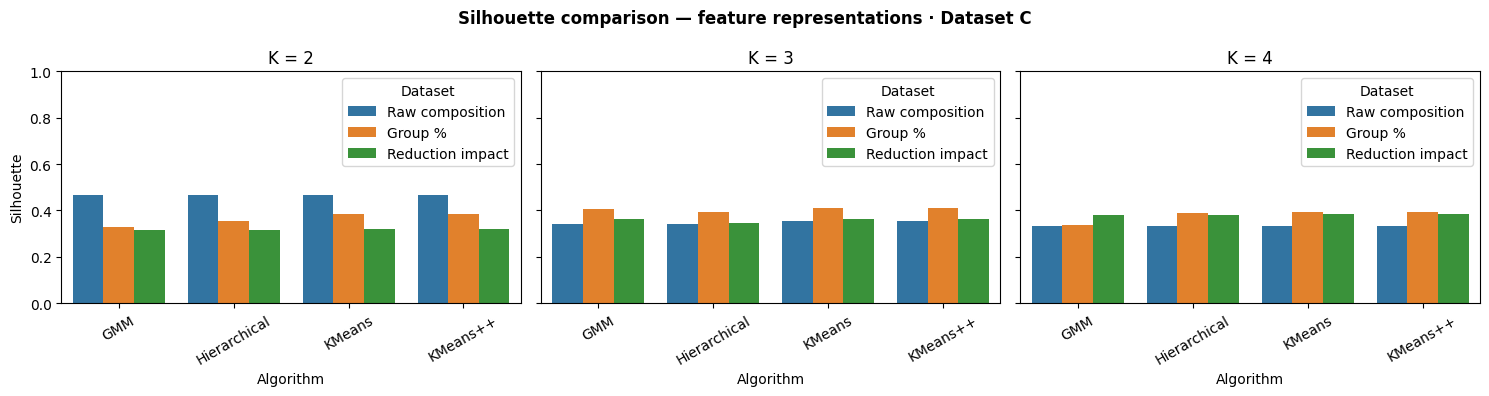

In [21]:
# Grouped bar chart: raw vs group % vs reduction — Dataset C
# Requires re-running raw clustering (same as modeling_clusterization)
summary_C_raw, _ = modl.run_all(df_C, ks=KS, seed=SEED)

plot.plot_silhouette_comparison(
    summaries=[
        (summary_C_raw,   "Raw composition"),
        (summary_C_group, "Group %"),
        (summary_C_reduc, "Reduction impact"),
    ],
    ks=KS,
    title="Silhouette comparison — feature representations · Dataset C",
)